# Rolling window with PCA approach

In this notebook we extend the exploration using most frequent lemmas and PCA in notebook 1 in three ways.
 - We add spaCy's morphological and POS tags as features alongside lemmas.
 - We build a simple linear discriminator on speech vs. narrative using PC1 and PC2.
 - We project a set of rolling window samples using the PCA model and score each window for its distance from the linear model.

## Preliminaries

### Import statements

In [1]:
import os
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import ccc2026

### Setup

Initialize local data if necessary. See `1 - Author and speech signal.ipynb` for further details.

In [2]:
ccc2026.setup()

### Global values

See `src/ccc2026/config.py`

In [3]:
# local directory structure
tokens_dir = os.path.join(ccc2026.CONFIG["data_dir"], "tokens")
plot_dir = ccc2026.CONFIG["plot_dir"]

# token files to process
token_files = [filename for _, filename in ccc2026.CONFIG["texts"]]

# Notebook-wide random number seed
SEED = 1

### Load tokens

In [4]:
# concatenate all per-text token tables into one corpus-wide frame
tokens = pd.concat(
    [pd.read_csv(os.path.join(tokens_dir, filename), dtype=str) for filename in token_files],
    ignore_index=True,
)
print(f"Loaded {len(tokens)} tokens from {len(token_files)} texts.")

# break line_id into prefix (book) and line number
tokens[["pref", "line"]] = pd.DataFrame(tokens["line_id"].str.split("_").tolist(), index=tokens.index)

Loaded 429774 tokens from 6 texts.


#### Select most frequent lemmas

In [5]:
# corpus-wide count for all non-punctuation lemmas, from most frequent to least
corpus_lemma_count = tokens["lemma"].value_counts()

# a list of the top lemmas
top_lemmas = corpus_lemma_count.head(100).index

# show results
display(corpus_lemma_count.loc[top_lemmas])

lemma
δέ        21339
καί       13671
ὁ          9589
τε         5574
ἐγώ        3783
          ...  
τίθημι      530
πέλω        530
ἄγω         525
σύν         520
βαίνω       519
Name: count, Length: 100, dtype: int64

### Preprocess POS tags
#### Select all tags

In [6]:
# get corpus-wide POS counts
corpus_pos_count = tokens["pos"].value_counts()
display(corpus_pos_count)

# drop very infrequent tags
pos_cutoff = 100
top_pos = corpus_pos_count[corpus_pos_count > pos_cutoff].index

pos
NOUN     122396
VERB      82098
ADJ       68072
PART      43638
ADV       33412
ADP       25819
PRON      25287
CCONJ     18309
SCONJ      4504
AUX        3489
DET        1588
INTJ        614
NUM         485
X            57
PROPN         6
Name: count, dtype: int64

### Preprocess morphological features
#### Consolidate all morphs into one column
Note: assumes there are no value collisions across morph columns, which is true for this data.

In [7]:
# melt morph column values
morph = tokens.melt(
        value_vars=["verbform", "mood", "tense", "voice", "person", "number", "case", "gender"],
        ignore_index = False,
    ).dropna()

# agg as list, add to token table
tokens["morph"] = morph.groupby(morph.index).agg(morph = ("value", list))

#### Rank morph features and select all

In [8]:
# get corpus wide morph counts
corpus_morph_count = tokens["morph"].explode().value_counts()
display(corpus_morph_count)

# drop anomalously low
morph_cutoff = 1000
top_morph = corpus_morph_count[corpus_morph_count > morph_cutoff].index

morph
Sing        219647
Masc        133310
Acc          79926
Plur         75943
Nom          74252
Fem          64224
Act          59682
Fin          54853
Past         52041
Ind          46386
3            43396
Neut         42976
Gen          42714
Dat          42265
Pres         29354
Part         25061
Mid          23631
2             5859
Inf           5680
1             5678
Sub           3263
Voc           3120
Fut           3003
Imp           2952
Opt           2252
Pass          2204
Dual          1510
Pqp           1190
Fem;Masc         1
Name: count, dtype: int64

## Training samples

Here we divide all the tokens into groups by author and narrative/speech. There's a special group just for Odysseus' apologue. From these groups, we then generate samples of `sample_size` random tokens without replacement. We'll use these samples to train a simple model to discriminate speech from narrative.

In [ ]:
def run_training(feature_set, sample_size=1000, seed=SEED):
    # Narratological groups
    nr_mask = tokens["speaker"].isna()
    sp_mask = tokens["speaker"].notna() & tokens["speaker"].ne("Odysseus-Apologue")

    # default group is "other"
    nara_group_ids = pd.Series("oth", index=tokens.index)
    nara_group_ids[nr_mask] = "nar"
    nara_group_ids[sp_mask] = "spk"

    # Authorship groups
    auth_group_ids = tokens["work"].str.slice(0,4)

    # Combined two-factor group
    group_ids = auth_group_ids + "-" + nara_group_ids

    # Initialize random number generator
    rng = np.random.default_rng(seed)

    # Sample labels
    sample_ids = pd.Series(index=tokens.index)
    for group in group_ids.unique():
        n_toks = sum(group_ids==group)
        sample_ids.loc[group_ids==group] = rng.permutation(n_toks) // sample_size
    sample_ids = group_ids + "-" + sample_ids.map(lambda f: f"{int(f):03d}")

    # Calculate sample sizes
    tokens_per_sample = tokens.groupby(sample_ids).size()

    # drop stub samples (fewer than sample_size tokens, from each group's
    # leftover remainder) rather than let an undersized, noisy sample skew
    # the fit — see "1 - Author and speech signal.ipynb" for the same fix
    stub_list = tokens_per_sample[tokens_per_sample < sample_size]
    sample_ids = sample_ids.where(~sample_ids.isin(stub_list.index))
    tokens_per_sample = tokens.groupby(sample_ids).size()

    # use a different scaler for each feat class
    scalers = {}

    # collect output vectors for each feat class
    parts = []

    for col, features in feature_set.items():

        # Generate feature tallies
        raw = (tokens[col]
            .explode()
            .where(lambda x: x.isin(features))
            .pipe(pd.get_dummies)
            .groupby(level=0).agg("sum")
            .groupby(sample_ids).agg("sum")
        )
        
        # normalize as freq / 1000 words
        normalized = raw.div(tokens_per_sample, axis=0) * 1000

        # scale
        scaler = StandardScaler()
        scaled = pd.DataFrame(
            data = scaler.fit_transform(normalized),
            columns = [f"{col}_{f}" for f in features],
            index = normalized.index,
        )
        scalers[col] = scaler
        parts.append(scaled)

    # combine all vectors into one table
    composite = pd.concat(parts, axis=1)
    
    # principal components analysis
    pca_model = PCA(n_components=3)

    pca = pd.DataFrame(
        data = pca_model.fit_transform(composite),
        columns = ["PC1", "PC2", "PC3"],
        index = composite.index,
    )

    # logistic regression on nar/spk only
    mask = ~pca.index.str.contains("-oth-")
    X = pca.loc[mask, ["PC1", "PC2"]].values
    y = pca.index[mask].str.contains("spk").astype(int)
    clf = LogisticRegression()
    clf.fit(X, y)

    # used for labeling PCA graphs
    nara_label = nara_group_ids.groupby(sample_ids).agg("first").values
    auth_label = auth_group_ids.groupby(sample_ids).agg("first").values

    # difference of z-scores
    diff = (
            composite.loc[nara_label=="spk"].agg("mean") -
            composite.loc[nara_label=="nar"].agg("mean")
        ).sort_values()
 
    # bundle outputs
    return dict(
        feature_set = feature_set,
        sample_size = sample_size,
        seed = seed,
        nara_label = nara_label,
        auth_label = auth_label,
        scalers = scalers,
        pca_model = pca_model,
        scaled = scaled,
        pca = pca,
        clf = clf,
        diff = diff,
    )

**Note on feature scaling and PCA weighting.** Each feature block (lemma, POS, morph) is standardized independently — every feature within a block ends up with unit variance — before the blocks are concatenated and passed to PCA. Since PCA responds to the total variance contributed by each block, and each feature contributes about one unit, the lemma block (100 features) carries roughly 100 units of variance vs. ~15 for POS and ~29 for morph. So the lemma features implicitly dominate the principal components simply because there are more of them, not necessarily because they're individually more discriminative. This is the intended emphasis here (lexical signal is our primary interest), but it's worth keeping in mind when interpreting which features drive PC1/PC2, or if the feature sets are changed.

#### run training

In [10]:
feature_set = {
    "lemma": top_lemmas,
    "pos": top_pos,
    "morph": top_morph,
}

train = run_training(feature_set)

### Plot

In [17]:
def plot_training(training, filename, show_decision_boundary=True):
    '''plot first two principal components of training data'''

    work_order = ["Ilia", "Odys", "Argo", "Post", "Sack", "Dion"]
    class_order = ["nar", "spk", "oth"]

    # plot using Seaborn
    g = sns.relplot(data=training["pca"],
        x = "PC1",
        y = "PC2",
        hue = training["auth_label"],
        hue_order = work_order,
        style = training["nara_label"],
        style_order = class_order,
        palette = "colorblind",
        legend = "full",
    )

    # set figure size
    g.figure.set_size_inches(7,4)

    # get text of default legend
    all_handles = g._legend.legend_handles
    all_labels = [t.get_text() for t in g._legend.get_texts()]
    # remove default legend
    g._legend.remove()

    # divide legend text into hue, style labels
    hue_handles, hue_labels = [], []
    style_handles, style_labels = [], []
    for h, l in zip(all_handles, all_labels):
        if l in work_order:
            hue_handles.append(h); hue_labels.append(l)
        elif l in class_order:
            style_handles.append(h); style_labels.append(l)

    # generate two legends, one for hue and one for style
    leg1 = g.ax.legend(hue_handles, hue_labels, title="Work",
                     bbox_to_anchor=(1.01, 1), loc="upper left", frameon=False)
    g.ax.add_artist(leg1)  # keep leg1 when adding leg2
    g.ax.legend(style_handles, style_labels, title="Text Class",
              bbox_to_anchor=(1.01, 0.5), loc="upper left", frameon=False)

    # add decision boundary
    if show_decision_boundary:
    
        # get the axis for the existing plot
        xlim = g.ax.get_xlim()
    
        # solve for y at each x endpoint: coef[0]*x + coef[1]*y + intercept = 0
        #   => y = -(coef[0]*x + intercept) / coef[1]
        w = training["clf"].coef_[0]
        b = training["clf"].intercept_[0]
        xs = np.array(xlim)
        ys = -(w[0] * xs + b) / w[1]
        
        g.ax.plot(xs, ys, "k--", linewidth=1)
        g.ax.set_xlim(xlim)  # restore limits so the line doesn't expand the plot

    # export
    g.savefig(os.path.join(plot_dir, filename),
        dpi = 300,
        bbox_inches = "tight",
    )
    
    plt.show()

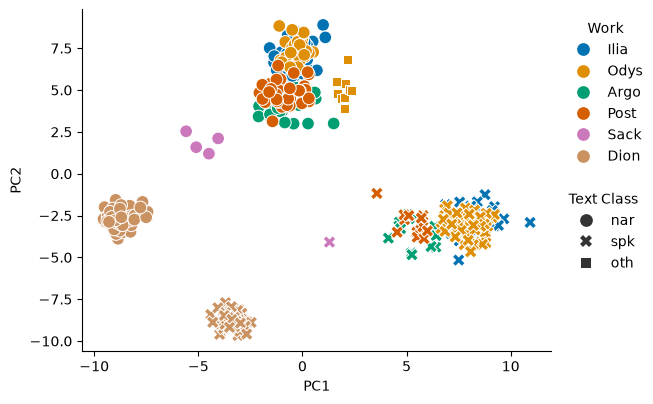

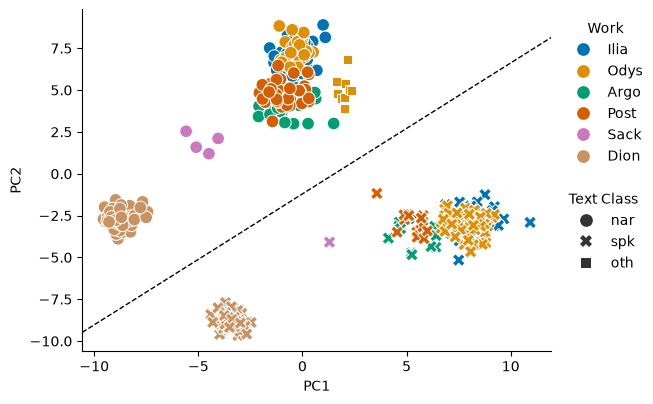

In [18]:
plot_training(train, filename="no_boundary.png", show_decision_boundary=False)
plot_training(train, filename="with_boundary.png", show_decision_boundary=True)

## Calculate rolling samples

In [13]:
def rolling_samples(training, window_size=500, min_ratio=0.7):

    # how many tokens in each sample
    tokens_per_sample = (
        tokens["lemma"]
        .rolling(window=window_size, center=True,
                 min_periods=int(window_size * min_ratio))
        .agg("count")
        .fillna(0)
        .astype(int)
    )

    # calculate one normalized, scaled feature vector per col
    parts = []
    for col, features in training["feature_set"].items():

        # raw count per sample
        raw = (tokens[col]
            .explode()
            .where(lambda x: x.isin(features))
            .pipe(pd.get_dummies)
            .groupby(level=0).agg("sum")
            .rolling(window=window_size, center=True, min_periods=int(window_size * 0.7))
            .agg("sum")
            .fillna(0)
            .astype(int)
        )

        # normalize by 1000 tokens
        normalized = raw.div(tokens_per_sample, axis=0) * 1000

        # scaled
        scaled = pd.DataFrame(
            data = training["scalers"][col].transform(normalized),
            columns = [f"{col}_{f}" for f in features],
            index = raw.index,
        )
        
        parts.append(scaled)

    # combine all vectors in one table
    composite = pd.concat(parts, axis=1)

    # remove NaN rows
    valid = composite.dropna()

    # transform vectors using pre-fitted pca model
    pca = pd.DataFrame(
        data = training["pca_model"].transform(valid),
        columns = ["PC1", "PC2", "PC3"],
        index = valid.index,
    )
    
    # calculate speechiness score
    X = pca[["PC1", "PC2"]].values
    proj = X @ training["clf"].coef_.T + training["clf"].intercept_
    
    speech_score = pd.DataFrame(dict(
            work = tokens.loc[pca.index, "work"],
            pref = tokens.loc[pca.index, "pref"],
            line = tokens.loc[pca.index, "line"],
            speech_id = tokens.loc[pca.index, "speech_id"],
            score = proj.flatten(), 
        ),
        index = pca.index)

    return dict(
        window_size = window_size,
        min_ratio = min_ratio,
        speech_score = speech_score,
    )

In [14]:
test = rolling_samples(train)

### Plot speech score by verse line

In [15]:
def plot_rolling(data, work, pref, filename=None):
    '''Project rolling window using the trained PCA model'''

    # select just the data from one work/book
    mask = (data["speech_score"]["work"] == work) & (data["speech_score"]["pref"] == pref)

    # plot using Seaborn
    g = sns.relplot(
        x = data["speech_score"][mask].index,
        y = data["speech_score"][mask].score,
        kind = "line",
    )

    # give the graph a title
    g.set(
        title = work + " " + pref.lstrip("0"),
        xlabel = "line",
    )

    # set output size
    g.figure.set_size_inches(8, 4)

    # set x-tics
    xmin = data["speech_score"][mask].index.min()
    xmax = data["speech_score"][mask].index.max()
    ymin = data["speech_score"]["score"].min()
    ymax = data["speech_score"]["score"].max()

    x_ticks = []
    x_tick_labels = []
    for idx in data["speech_score"][mask].index:
        ln = data["speech_score"].loc[idx, "line"]
        if int(ln) % 50 == 0:
            label = ln.lstrip("0")
            if label not in x_tick_labels:
                x_ticks.append(idx)
                x_tick_labels.append(label)
    g.ax.plot([xmin,xmax], [0,0], "k--", lw=1)
    g.set(
        xticks = x_ticks,
        xticklabels = x_tick_labels,
        xlim = (xmin, xmax),
        ylim = (ymin, ymax),
    )

    # plot speeches as vertical grey bars
    speech_data = data["speech_score"].dropna(subset=["speech_id"])
    for sid, group in speech_data.groupby("speech_id"):
        g.ax.axvspan(group.index.min(), group.index.max(), alpha=0.15, color="gray", linewidth=0)

    # export figure
    filename = f"{work}_{pref}.png"
    g.savefig(os.path.join(plot_dir, filename))
    
    plt.show()

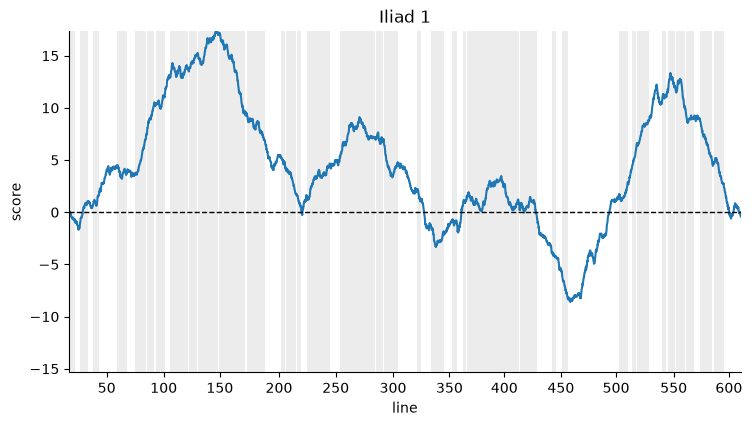

In [16]:
plot_rolling(data=test, work="Iliad", pref="01")